In [1]:
#| default_exp models.ml_forecaster

In [2]:
#| export
from __future__ import annotations
from typing import List, Dict, Optional, Callable, Tuple, Any, Union
import numpy as np
import pandas as pd
import copy
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from peshbeen.model_selection import SplitTimeSeries
from peshbeen.statstools import lr_trend_model, forecast_trend
from peshbeen.transformations import (box_cox_transform, back_box_cox_transform,
                                      rolling_quantile, expanding_mean, expanding_std, expanding_quantile)
from peshbeen.helpers import seasonal_diff, undiff_ts, invert_seasonal_diff
from sklearn.compose import ColumnTransformer
# dot not show warnings
import warnings
warnings.filterwarnings("ignore")

class ml_forecaster:

    def __init__(
        self,
        model: Any,
        target_col: str,
        lags: Optional[Union[int, List[int]]] = None,
        lag_transform: Optional[list] = None,
        difference: Optional[int] = None,
        seasonal_diff: Optional[int] = None,
        trend: Optional[str] = None,
        pol_degree: int = 1,
        ets_params: Optional[Dict[str, Any]] = None,
        change_points: Optional[List[int]] = None,
        box_cox: Union[bool, float, int] = False,
        box_cox_biasadj: bool = False,
        cat_variables: Optional[List[str]] = None,
        categorical_encoder: Optional[Any] = None
        ) -> None:

        """
        Initialize the ml_forecaster with the specified model and preprocessing options.

        Parameters
        ----------
        model : Any
            A regression model object (e.g. LGBMRegressor(), XGBRegressor(), CatBoostRegressor(), LinearRegression(), etc.)
        target_col : str
            Name of the target variable column in the input DataFrame.
        lags : int or list of int, optional
            Lags to include as features. If an integer is provided, lags from 1 to that integer will be included. If a list of integers is provided, those specific lags will be included. Default is None (no lag features).
        lag_transform : list of function objects, optional
            List of lag-transform function objects to apply to the target variable (e.g. [expanding_mean(shift=1), rolling_std(window_size=3, shift=1)]). Each function should take a pandas Series as input and return a Series of the same length. Default is None (no lag transforms).
        difference : int, optional
            Order of ordinary differencing to apply to the target variable (e.g. 1 for first difference). Default is None (no differencing).
        seasonal_diff : int, optional
            Seasonal period for seasonal differencing (e.g. 12 for monthly data with yearly seasonality). Default is None (no seasonal differencing).
        trend : str, optional
            Trend strategy to use. Options are 'linear' for linear trend removal, 'ets' for ETS-based trend removal, 'feature_lr' for using linear trend components as features, and 'feature_ets' for using ETS trend components as features. Default is None (no trend handling).
        pol_degree : int, optional
            Degree of polynomial trend to fit when using 'linear' or 'feature_lr' trend strategy. Default is 1 (linear trend).
        ets_params : Dict[str, Any], optional
            Dictionary of parameters for the ExponentialSmoothing model when using 'ets' trend strategy. The keys should be the parameter names and the values should be the parameter values. Default is None (use default ETS parameters).
        change_points : list of int, optional
            List of indices in the time series where change points occur for piecewise linear trend fitting. Only used when trend strategy is 'linear' or 'feature_lr'. Default is None (no change points, fit a single linear trend).
        box_cox : bool or float or int, optional
            Whether to apply Box-Cox transformation to the target variable. If a float or int value is provided, it will be used as the lambda parameter for the Box-Cox transformation. If True, the lambda parameter will be estimated from the data.
        box_cox_biasadj : bool, optional
            Whether to apply bias adjustment when inverting the Box-Cox transformation on forecasts. Default is False.
        cat_variables : list of str, optional
            List of categorical feature column names. If provided, these columns will be treated as categorical variables and encoded accordingly. Default is None (no categorical variables).
        categorical_encoder : object, optional
            Categorical encoder object (e.g. OneHotEncoder(), MeanEncoder(), etc.) to apply to the categorical variables specified in cat_variables. The encoder should have fit() and transform() methods that can be applied to the input DataFrame. Default is None (no categorical encoding) and if None, categorical variables can only be used if the model can handle them natively (e.g. LGBM or CatBoost).

        Returns
        -------
        None
        """

        self.model = model
        self.model_name = self.model.__class__.__name__
        self.target_col = target_col
        self.cat_variables = cat_variables
        self.cat_encoder = categorical_encoder

        if self.cat_variables is not None and self.cat_encoder is None:
            if self.model_name not in ["LGBMRegressor", "CatBoostRegressor"]:
                raise ValueError(
                    "Model must be LGBMRegressor or CatBoostRegressor to handle categorical variables without a specified encoder "
                    "(or provide an encoder such as OneHotEncoder/MeanEncoder)."
                )
            
        self.cps = change_points
        self.pol = pol_degree
        if isinstance(box_cox, bool):
            self.box_cox = box_cox
            self.lamda = None
        elif isinstance(box_cox, (float, int)):
            self.box_cox = True
            self.lamda = box_cox
        self.biasadj = box_cox_biasadj
        self.difference = difference
        self.season_diff = seasonal_diff
        self.lag_transform = lag_transform

        # ── trend ─────────────────────────────────────────────────────────────
        self.trend = trend
        if self.trend == "ets":
            self.ets_model = {}
            self.ets_fit = {}
            if ets_params is not None:
                # make sure ets_params is a dict with keys for both constructor and fit params
                if not isinstance(ets_params, dict):
                    raise TypeError("ets_params must be a dictionary with keys for both constructor and/or fit parameters.")
                # ExponentialSmoothing constructor params
                constructor_params = ["trend","damped_trend", "seasonal","seasonal_periods","initialization_method",
                                      "initial_level","initial_trend", "initial_seasonal","bounds","dates","freq","missing"]

                # ExponentialSmoothing.fit params
                fit_params = ["optimized","smoothing_level","smoothing_trend","smoothing_seasonal","damping_trend",
                    "remove_bias","start_params","method","minimize_kwargs","use_brute"]
                for param in constructor_params:
                    if param in ets_params:
                        self.ets_model[param] = ets_params[param]
                for param in fit_params:
                    if param in ets_params:
                        self.ets_fit[param] = ets_params[param]


        # ── lags ──────────────────────────────────────────────────────────────
        if lags is None:
            self.n_lag = None
        elif isinstance(lags, int):
            self.n_lag = list(range(1, lags + 1))
        elif isinstance(lags, list):
            if not all(isinstance(l, int) for l in lags):
                raise TypeError("lags list must contain only integers.")
            self.n_lag = lags
        else:
            raise TypeError("lags must be an int or a list of ints.")
        
        # ── placeholders set during fit ───────────────────────────────────────
        self.tuned_params = None
        self.actuals = None
        self.prob_forecasts = None

    # ─────────────────────────────────────────────────────────────────────────
    # DATA PREPARATION
    # ─────────────────────────────────────────────────────────────────────────

    def data_prep(self,
                  df: pd.DataFrame) -> pd.DataFrame:
        """
        Prepare the data for modeling by applying the specified transformations and feature engineering steps.

        Parameters
        ----------
        df : pd.DataFrame
            Input DataFrame containing the target and any feature columns.
        """
        dfc = df.copy()

        # ── categorical encoding ──────────────────────────────────────────────
        if self.cat_variables is not None:
            dfc = self.create_encoded_features(dfc)

        if self.target_col not in dfc.columns:
            return dfc.dropna()
        
        self.orig_target = dfc[self.target_col].values # store for generating in sample residuals later
        # ── Box-Cox ───────────────────────────────────────────────────────────
        if self.box_cox:
            self.is_zero = np.any(np.array(dfc[self.target_col]) < 1)
            self.trans_data, self.lamda = box_cox_transform(
                x=dfc[self.target_col], shift=self.is_zero, box_cox_lmda=self.lamda
            )
            dfc[self.target_col] = self.trans_data

        # ── Trend removal ─────────────────────────────────────────────────────
        if self.trend is not None:
            self.len = len(df)
            self.target_orig = dfc[self.target_col].copy()

            if self.trend == "linear":
                if self.cps is not None:
                    self.trend_vals, self.lr_model, self.X_trend = lr_trend_model(
                        dfc[self.target_col], degree=self.pol,
                        breakpoints=self.cps, type='piecewise'
                    )
                else:
                    self.trend_vals, self.lr_model, self.X_trend = lr_trend_model(
                        dfc[self.target_col], degree=self.pol
                    )

            elif self.trend == "ets":
                self.ets_model_fit = ExponentialSmoothing(
                    dfc[self.target_col], **self.ets_model
                ).fit(**self.ets_fit)
                self.trend_vals = self.ets_model_fit.fittedvalues.values

            else:
                raise ValueError(
                    f"Unknown trend type '{self.trend}'. "
                    "Use 'linear' or 'ets'."
                )
            
            dfc[self.target_col] = dfc[self.target_col] - self.trend_vals

        # ── Ordinary differencing ─────────────────────────────────────────────
        if self.difference is not None or self.season_diff is not None:
            self.orig = dfc[self.target_col].tolist()
            if self.difference is not None:
                dfc[self.target_col] = np.diff(
                    dfc[self.target_col], n=self.difference,
                    prepend=np.repeat(np.nan, self.difference)
                )

        # ── Seasonal differencing ─────────────────────────────────────────────
            if self.season_diff is not None:
                self.orig_d = dfc[self.target_col].tolist()
                dfc[self.target_col] = seasonal_diff(dfc[self.target_col], self.season_diff)

        # ── Lag features ──────────────────────────────────────────────────────
        if self.n_lag is not None:
            for lag in self.n_lag:
                dfc[f"{self.target_col}_lag_{lag}"] = dfc[self.target_col].shift(lag)

        # ── Lag transforms ────────────────────────────────────────────────────
        if self.lag_transform is not None:
            for func in self.lag_transform:
                if isinstance(func, (expanding_std, expanding_mean)):
                    dfc[f"{func.__class__.__name__}_shift_{func.shift}"] = func(dfc[self.target_col])
                elif isinstance(func, expanding_quantile):
                    dfc[f"{func.__class__.__name__}_shift_{func.shift}_q{func.quantile}"] = func(dfc[self.target_col])
                elif isinstance(func, rolling_quantile):
                    dfc[f"{func.__class__.__name__}_{func.window_size}_shift_{func.shift}_q{func.quantile}"] = func(dfc[self.target_col])
                else:
                    dfc[f"{func.__class__.__name__}_{func.window_size}_shift_{func.shift}"] = func(dfc[self.target_col])

        return dfc.dropna()

    # ─────────────────────────────────────────────────────────────────────────
    # ENCODE CATEGORICAL FEATURES
    # ─────────────────────────────────────────────────────────────────────────

    def create_encoded_features(self,
                    df: pd.DataFrame
                    ) -> pd.DataFrame:
        
        ## make sure categorical variables are treated as category dtype for encoding
        for col in self.cat_variables:
            df[col] = df[col].astype('category')
        ## if fit has been called but forecat has not been called yet, we can fit the encoder on the training data and store it for use during forecasting

        if self.cat_encoder is not None:

            if self.target_col in df.columns: # if we have target values, we are in the fit stage and can fit the encoder on the training data (if not already fitted) and then transform the data for model fitting
                num_cols = [c for c in df.columns if c not in self.cat_variables + [self.target_col]]

                # pass_cols = self.cat_variables + num_cols
                self.preprocess = ColumnTransformer(
                    transformers=[("cat", self.cat_encoder, self.cat_variables), ("num", "passthrough", num_cols)],
                    remainder="drop",
                    verbose_feature_names_out=False
                ).set_output(transform="pandas")

                X_train = self.preprocess.fit_transform(df.drop(columns=[self.target_col]), y=df[self.target_col])
                return pd.concat([df[[self.target_col]], X_train], axis=1)
            
            else: # if we do not have target values, we are in the forecast stage and can just transform the data using the already fitted encoder
                return self.preprocess.transform(df)
        else:
            return df

    # ─────────────────────────────────────────────────────────────────────────
    # FIT
    # ─────────────────────────────────────────────────────────────────────────

    def fit(self,
            df: pd.DataFrame
            ) -> None:
        """
        Fit the model to the training data after applying the specified data preparation steps.

        Parameters
        ----------
        df : pd.DataFrame
            Training DataFrame containing the target and any feature columns.
        """
        
        model_df = self.data_prep(df)
        self.X = model_df.drop(columns=[self.target_col])
        self.y = model_df[self.target_col]
        
        fit_kwargs = {}

        if self.model_name == "LGBMRegressor" and self.cat_encoder is None:
            fit_kwargs = {"categorical_feature": self.cat_variables}
        elif self.model_name == "CatBoostRegressor" and self.cat_encoder is None:
            fit_kwargs = {"cat_features": self.cat_variables, "verbose": False}

        self.model_fit = self.model.fit(self.X, self.y, **fit_kwargs)

    # ─────────────────────────────────────────────────────────────────────────
    # predict_in_sample
    # ─────────────────────────────────────────────────────────────────────────

    def predict_in_sample(self) -> np.ndarray:
        """
        Generate in-sample predictions and residuals for the training data. This can be useful for diagnostic purposes, such as checking for patterns in the residuals or calculating in-sample performance metrics.

        Returns
        -------
        np.ndarray
            In-sample fitted values and residuals for the training data.
        """

        # if .fit has not been called yet, error out
        if not hasattr(self, "model_fit"):
            raise ValueError("Model has not been fitted yet. Call .fit() before predict_in_sample().")
        
        fitted_values = self.model_fit.predict(self.X)
        fit_len = len(fitted_values)
        self.in_samp_resids = self.y - fitted_values
        if not self.box_cox:
            self.fitted_values = self.orig_target[-fit_len:] + self.in_samp_resids # start with original target values and add residuals to get fitted values in original scale (after all transformations are inverted in the correct order below)
            
        else:
            bc_fitted= self.trans_data[-fit_len:] + self.in_samp_resids
            self.fitted_values = back_box_cox_transform(
                y_pred=bc_fitted, lmda=self.lamda,
                shift=self.is_zero)
            self.in_samp_resids = self.orig_target[-fit_len:] - self.fitted_values
        # add NaNs for the initial periods where fitted values are not available due to lag features        if fit_len < len(self.orig_target):
        self.fitted_values = np.concatenate([np.repeat(np.nan, len(self.orig_target) - fit_len), self.fitted_values])

    # ─────────────────────────────────────────────────────────────────────────
    # INFORMATION CRITERIA
    # ─────────────────────────────────────────────────────────────────────────

    def _k(self) -> int:
        """Number of model parameters (approximate)."""
        base = self.X.shape[1]
        if isinstance(self.model, (LinearRegression, Ridge, Lasso, ElasticNet)):
            return base + 2   # coefficients + intercept + variance
        return base + 1       # coefficients + variance

    def _ic_base(self):
        k = self._k()
        n = len(self.y)
        rss = np.sum((self.y.to_numpy() - self.model_fit.predict(self.X)) ** 2)
        return k, n, rss

    @property
    def aic(self) -> float:
        k, n, rss = self._ic_base()
        return n * np.log(rss / n) + 2 * k

    @property
    def aicc(self) -> float:
        k, n, rss = self._ic_base()
        aic = n * np.log(rss / n) + 2 * k
        return aic + (2 * k * (k + 1)) / (n - k - 1)

    @property
    def bic(self) -> float:
        k, n, rss = self._ic_base()
        return n * np.log(rss / n) + k * np.log(n)

    @property
    def hqc(self) -> float:
        k, n, rss = self._ic_base()
        return n * np.log(rss / n) + 2 * k * np.log(np.log(n))

    def copy(self):
        return copy.deepcopy(self)

    # ─────────────────────────────────────────────────────────────────────────
    # FORECAST
    # ─────────────────────────────────────────────────────────────────────────

    def forecast(
        self,
        H: int,
        exog: Optional[pd.DataFrame] = None
    ) -> np.ndarray:
        """
        Recursive multi-step forecast.

        Parameters
        ----------
        H : int
            Forecast horizon.
        exog : pd.DataFrame | None, default None
            Optional dataframe of future regressors.

        Returns
        -------
        np.ndarray
            Forecast values of length `H`.
        """
        # ── Prepare exog ──────────────────────────────────────────────────────
        if exog is not None:
            if self.cat_variables is not None:
                exog = self.data_prep(exog)

        # Rolling lag history
        lags = self.y.tolist()

        # ── Pre-compute trend forecasts ───────────────────────────────────────
        if self.trend is not None:
            if self.trend == "linear":
                trend_forecast, X_trend_forecast = forecast_trend(
                    model=self.lr_model, H=H, start=self.len,
                    degree=self.pol, breakpoints=self.cps
                )
            else:  # ets or feature_ets
                trend_forecast = np.array(self.ets_model_fit.forecast(H))

        # ── Recursive forecast loop ───────────────────────────────────────────
        predictions = []

        for i in range(H):
            # Exogenous features for step i
            x_var = exog.iloc[i, :].tolist() if exog is not None else []

            # Lag features
            inp_lag = []
            if self.n_lag is not None:
                inp_lag.extend([lags[-lag] for lag in self.n_lag])

            # Lag-transform features
            transform_lag = []
            if self.lag_transform is not None:
                series_array = np.array(lags)
                for func in self.lag_transform:
                    transform_lag.append(func(series_array, is_forecast=True).to_numpy()[-1])

            inp = x_var + inp_lag + transform_lag
            df_inp = pd.DataFrame(np.array(inp).reshape(1, -1), columns=self.X.columns)

            if (self.model_name in ['LGBMRegressor', 'CatBoostRegressor']) and self.cat_encoder is None:
                for c in df_inp.columns:
                    if c in (self.cat_variables or []):
                        df_inp[c] = df_inp[c].astype(int).astype('category')
                    else:
                        df_inp[c] = df_inp[c].astype('float64')

            pred = self.model_fit.predict(df_inp)[0]
            lags.append(pred)
            predictions.append(pred)

        # ── Post-processing ───────────────────────────────────────────────────
        forecasts = np.array(predictions)

        # Add back removed trend
        if self.trend is not None:
            if self.trend in ("linear", "ets"):
                forecasts = forecasts + trend_forecast

        # Invert seasonal differencing
        if self.season_diff is not None:
            forecasts = invert_seasonal_diff(self.orig_d, forecasts, self.season_diff)

        # Invert ordinary differencing
        if self.difference is not None:
            forecasts = undiff_ts(self.orig, forecasts, self.difference)

        # Non-negativity
        forecasts = np.array([max(0, x) for x in forecasts])

        # Invert Box-Cox
        if self.box_cox:
            forecasts = back_box_cox_transform(
                y_pred=forecasts, lmda=self.lamda,
                shift=self.is_zero, box_cox_biasadj=self.biasadj
            )

        return forecasts

    def cross_validate(self,
                       df: pd.DataFrame,
                       cv_split: int,
                       test_size: int,
                       metrics: List[Callable],
                       step_size: int = 1,
                       h_split_point: Optional[int] = None
                       ) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        Run cross-validation using time series splits.

        Parameters
        ----------
        df : pd.DataFrame
            DataFrame containing the target and any feature columns.
        cv_split : int
            Number of cross-validation splits.
        test_size : int
            Number of periods in each test set.
        metrics : list of callable
            Metric functions (e.g. ``[MAE, RMSE]``) used to evaluate forecast accuracy across folds. Call ``.cv_summary()`` after cross-validation to retrieve the aggregated scores.
        step_size : int, default 1
            Step size to move the test window forward in each split.
        h_split_point : int or None, default None
            Optional index to split the test set into two parts for separate evaluation (e.g. to evaluate short-term vs long-term performance). If None, no split is done.
            
        Returns
        -------
        pd.DataFrame
            DataFrame containing overall performance metrics averaged across splits, and a DataFrame with predictions and true values for each split.
        """

        # self.get_feature_importance = pd.DataFrame()
        cv_df_ = pd.DataFrame()
        tscv = SplitTimeSeries(n_splits=cv_split, test_size=test_size, step_size=step_size)
        metrics_dict = {m.__name__: [] for m in metrics}
        if h_split_point is not None:
            metrics_dict1 = {m.__name__: [] for m in metrics}
            metrics_dict2 = {m.__name__: [] for m in metrics}
        for idx, (train_index, test_index) in enumerate(tscv.split(df)):
            train, test = df.iloc[train_index], df.iloc[test_index]
            x_test = test.drop(columns=[self.target_col])
            y_test = np.array(test[self.target_col])
            self.fit(train)
            exog_t = x_test if x_test.shape[1] > 0 else None
            bb_forecast = self.forecast(test_size, exog_t)
            # Evaluate each metric
            for m in metrics:
                if m.__name__ in ["MASE", "SMAE", "SRMSE", "RMSSE"]:
                    eval_val = m(y_test, bb_forecast, train[self.target_col])
                else:
                    eval_val = m(y_test, bb_forecast)
                metrics_dict[m.__name__].append(eval_val)
            if h_split_point is not None and isinstance(h_split_point, int):
                y_test_1, y_test_2 = y_test[:h_split_point-1], y_test[h_split_point-1:] # split true values into two parts based on h_split_point. -1 is subtracted from h_split_point to account for zero-based indexing and to ensure the split is done at the correct point in the array
                bb_forecast_1, bb_forecast_2 = bb_forecast[:h_split_point-1], bb_forecast[h_split_point-1:]
                for m in metrics:
                    if m.__name__ in ['MASE', 'SMAE', 'SRMSE', 'RMSSE']:
                        eval_val1 = m(y_test_1, bb_forecast_1, np.array(train[self.target_col]))
                        eval_val2 = m(y_test_2, bb_forecast_2, np.array(train[self.target_col]))
                    else:
                        eval_val1 = m(y_test_1, bb_forecast_1)
                        eval_val2 = m(y_test_2, bb_forecast_2)
                    metrics_dict1[m.__name__].append(eval_val1)
                    metrics_dict2[m.__name__].append(eval_val2)
            
            ## store results for this split
            split_results = {"cutoff": np.repeat(test.index[0], len(test)), "index": test.index,
                            "split": np.repeat(f"fold_{idx+1}", len(test)), "y_true": y_test, "y_pred": bb_forecast}
            cv_df_ = pd.concat([cv_df_, pd.DataFrame(split_results)], ignore_index=True)

            ## get feature importance for this split if available and store in dataframe
            # feature_importance_df = pd.DataFrame({'feature': self.model_fit.feature_names_in_, 'importance': self.model_fit.feature_importances_})
            # feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)
            # feature_importance_df['split'] = f"fold_{idx+1}"
            # self.get_feature_importance = pd.concat([self.get_feature_importance, feature_importance_df], ignore_index=True)

        overall_performance = [[m.__name__, np.mean(metrics_dict[m.__name__])] for m in metrics]
        overall_performance = pd.DataFrame(overall_performance).rename(columns={0: "eval_metric", 1: "overall_score"})
        if h_split_point is not None and isinstance(h_split_point, int):
            performance_1 = [[m.__name__, np.mean(metrics_dict1[m.__name__])] for m in metrics]
            performance_2 = [[m.__name__, np.mean(metrics_dict2[m.__name__])] for m in metrics]
            overall_performance = pd.DataFrame(overall_performance).rename(columns={0: "eval_metric", 1: "overall_score"})
            perf_1_df = pd.DataFrame(performance_1).rename(columns={0: "eval_metric", 1: f"1-{h_split_point}"})
            perf_2_df = pd.DataFrame(performance_2).rename(columns={0: "eval_metric", 1: f"{h_split_point+1}-{test_size}"})
            # merge all three dataframes
            overall_performance = overall_performance.merge(perf_1_df, on="eval_metric").merge(perf_2_df, on="eval_metric")

        self.cv_summary = overall_performance
        return cv_df_
    
    def get_cross_validated_features(self,) -> pd.DataFrame:
        """
        Retrieve feature importance for each validation fold after cross-validation.

        Returns
        -------
        pd.DataFrame
            DataFrame containing feature importance scores for each fold.
        """
        if not hasattr(self, "cv_summary"):
            raise ValueError("Cross-validation has not been run yet. Call .cross_validate() before get_cross_validated_features().")
        if self.model_name in ["LGBMRegressor", "CatBoostRegressor"]:
            feature_importance_df = pd.DataFrame(self.model_fit.feature_importances_, index=self.X.columns, columns=["importance"])
            return feature_importance_df.sort_values(by="importance", ascending=False)
        else:
            raise ValueError(f"Feature importance retrieval not implemented for model type '{self.model_name}'.")
    
    # a name for the class that is more descriptive of its purpose
    def get_name(self):
        return "ml_forecaster"

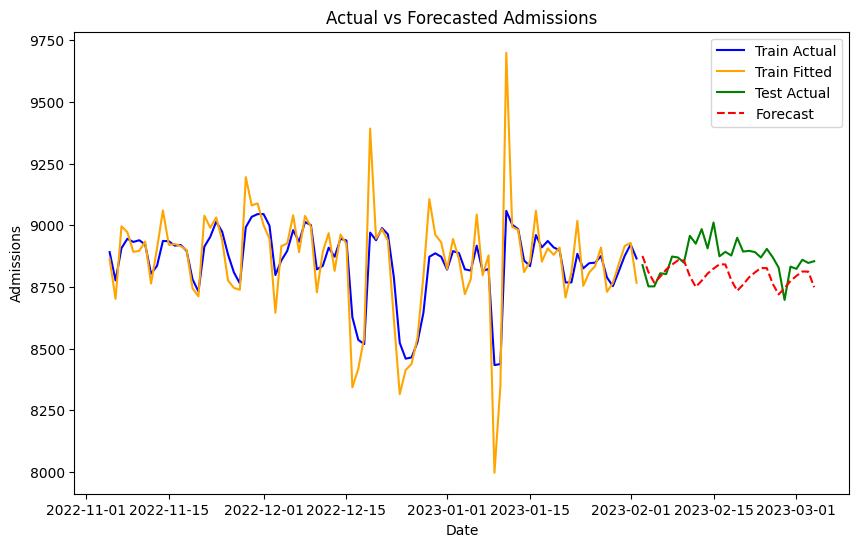

In [3]:
#| hide
from peshbeen.datasets import load_wales_admissions
# from feature_engine.encoding import OneHotEncoder, MeanEncoder, OrdinalEncoder, StringSimilarityEncoder, DecisionTreeEncoder
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
wales_admissions = load_wales_admissions()
wales_admissions["day_of_week"] = wales_admissions.index.dayofweek
wales_admissions["month"] = wales_admissions.index.month

cat_variables = ["day_of_week", "month"]
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False)
from sklearn.preprocessing import TargetEncoder

te = TargetEncoder(target_type="continuous")
# split the data into train and test sets
train = wales_admissions[:-30]
test = wales_admissions[-30:]

# import linear regression from sklearn
from sklearn.linear_model import LinearRegression
ml_linear = ml_forecaster(model=LinearRegression(),
              target_col='admissions', lags = 2,
              cat_variables=cat_variables, categorical_encoder=te)
ml_linear.fit(train)
# ml_linear.data_prep(train)
forecasts = ml_linear.forecast(H=30, exog=test[cat_variables])
ml_linear.predict_in_sample()
## plot actual vs forecasts
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train.index[-90:], train['admissions'][-90:], label='Train Actual', color='blue')
plt.plot(train.index[-90:], ml_linear.fitted_values[-90:], label='Train Fitted', color='orange')
plt.plot(test.index, test['admissions'], label='Test Actual', color='green')
plt.plot(test.index, forecasts, label='Forecast', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Admissions')
plt.title('Actual vs Forecasted Admissions')
plt.legend()
plt.show()

In [4]:
#| hide

from peshbeen.metrics import WMAPE, MAE, RMSE
mtrcs = [WMAPE, MAE, RMSE]
cv_results = ml_linear.cross_validate(df=train, cv_split=5, test_size=30, metrics=mtrcs, step_size=30)
cv_results.head()

,cutoff,index,split,y_true,y_pred
0,2022-09-06,2022-09-06,fold_1,8839,8828.004472
1,2022-09-06,2022-09-07,fold_1,8869,8840.105059
2,2022-09-06,2022-09-08,fold_1,8875,8848.677661
3,2022-09-06,2022-09-09,fold_1,8845,8847.820182
4,2022-09-06,2022-09-10,fold_1,8708,8804.284098
